## Insert Data into MongoDB

**Pipeline Overview:**
1. **Data Ingestion:** Insert csv data into MongoDB.
2. **Data Extraction:** Load data into Spark using from MongoDB.
3. **Transform & Analyze:** Perform joins, handle missing values, and calculate statistical insights.
4. **Data Loading:** Write the aggregated results directly back to MongoDB.

pipeline overview from Exercise_07

In [66]:
import csv
from pymongo import MongoClient

client = MongoClient("mongodb://127.0.0.1:27017/")
db = client["netflix"]

db["movies"].drop()
db["watch_history"].drop()
db["reviews"].drop()

with open("movies.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    movie_data = [row for row in reader]

db["movies"].insert_many(movie_data)
print(f"✅ Inserted {len(movie_data)} movies")

with open("watch_history.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    watch_data = [row for _, row in zip(range(105000), reader)]
    
with open("reviews.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    review_data = [row for row in reader]
db["reviews"].insert_many(review_data)

db["watch_history"].insert_many(watch_data)
print(f"✅ Inserted {len(watch_data)} watch records")

with open("recommendation_logs.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    recommendation_data = [row for row in reader]
db["recommendation"].insert_many(recommendation_data)


list_of_collections = db.list_collection_names()
list_of_collections

✅ Inserted 1040 movies
✅ Inserted 105000 watch records


['reviews', 'movies', 'recommendation', 'watch_history']

## Start Spark Session

In [63]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("NetflixAnalysis").getOrCreate()

In [67]:
movies = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("movies.csv")

watch = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("watch_history.csv")
    
review = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("reviews.csv")
    
recommedation = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("recommendation_logs.csv")

## Distribution of User watch time

In [33]:
#Data cleaning

movies = movies.dropDuplicates()

In [34]:
#Data transformation

from pyspark.sql.functions import col, year

movies = movies.withColumn("release_year", col("release_year").cast("int"))

In [35]:
#Join data

df = watch.join(movies, "movie_id")

In [36]:
df.groupBy("title").count().orderBy("count", ascending=False)

DataFrame[title: string, count: bigint]

In [37]:
from pyspark.sql.functions import col

df = df.withColumn(
    "watch_duration_minutes",
    col("watch_duration_minutes").cast("double")
)

df.groupBy("user_id").avg("watch_duration_minutes")

DataFrame[user_id: string, avg(watch_duration_minutes): double]

In [39]:
from pyspark.sql.functions import avg

user_watch = df.groupBy("user_id").agg(avg("watch_duration_minutes").alias("avg_watch_time"))

In [40]:
pdf = user_watch.toPandas()

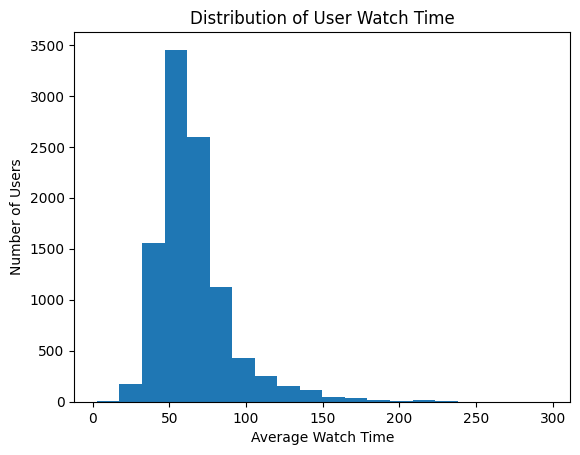

+-----------------+
|   avg_watch_time|
+-----------------+
|65.69223896059069|
+-----------------+



In [41]:
import matplotlib.pyplot as plt

# Sort and take top 10 users
top_users = pdf.sort_values(by="avg_watch_time", ascending=False).head(10)

plt.figure()
plt.hist(pdf["avg_watch_time"], bins=20)
plt.xlabel("Average Watch Time")
plt.ylabel("Number of Users")
plt.title("Distribution of User Watch Time")
plt.show()

df_watch_history = spark.read.csv(
    "watch_history.csv", 
    header=True, 
    inferSchema=True
)
df_watch_history.select(avg("watch_duration_minutes").alias("avg_watch_time")).show()

The overall distribution of user average watch time suggests that the average session takes around 66 minutes while most of the sessions range from 30 to 80 minutes.

## Total watch count and total watch time

In [110]:
df_joined = watch.join(movies, on="movie_id", how="inner")

df_joined.cache()

DataFrame[movie_id: string, session_id: string, user_id: string, watch_date: date, device_type: string, watch_duration_minutes: double, progress_percentage: double, action: string, quality: string, location_country: string, is_download: boolean, user_rating: int, title: string, content_type: string, genre_primary: string, genre_secondary: string, release_year: int, duration_minutes: double, rating: string, language: string, country_of_origin: string, imdb_rating: double, production_budget: double, box_office_revenue: double, number_of_seasons: double, number_of_episodes: double, is_netflix_original: boolean, added_to_platform: date, content_warning: boolean]

In [118]:
df_clean = df_joined.dropDuplicates(["user_id", "movie_id"])

df_movie_stats = df_clean.groupBy("movie_id", "title") \
    .agg(
        count("user_id").alias("watch_count_unique"),
        round(sum("watch_duration_minutes"), 2).alias("total_watch_time")
    )

In [119]:
df_top10 = df_movie_stats.orderBy("watch_count_unique", ascending=False).limit(10)

print("Top 10 Most Watched Movies:")
df_top10.show()

Top 10 Most Watched Movies:
+----------+--------------+------------------+----------------+
|  movie_id|         title|watch_count_unique|total_watch_time|
+----------+--------------+------------------+----------------+
|movie_0939|    Dragon War|               131|          6414.1|
|movie_0539|   Queen Queen|               126|          6953.2|
|movie_0908|      Love War|               124|          6561.8|
|movie_0398|    Hero Story|               124|          6761.2|
|movie_0074|      Dark Ice|               124|          7011.2|
|movie_0285| Dragon Dragon|               123|          7991.2|
|movie_0064|     Last City|               123|          7089.7|
|movie_0716|   Love Battle|               123|          8051.4|
|movie_0545|Little Mission|               122|          6234.4|
|movie_0727|  Last Journey|               122|          6697.4|
+----------+--------------+------------------+----------------+



The most watched title was Dragon war with 131 views. It is important to note that the total watch time for Love battle was highest so even though it has less views it has overall been watched for a longer period of time.

## Average imdb rating

In [99]:
df_joined = review.join(movies, on="movie_id", how="inner")
df_reviews = review.withColumnRenamed("rating", "review_rating")
df_joined.cache()

DataFrame[movie_id: string, review_id: string, user_id: string, rating: int, review_date: date, device_type: string, is_verified_watch: boolean, helpful_votes: double, total_votes: double, review_text: string, sentiment: string, sentiment_score: double, title: string, content_type: string, genre_primary: string, genre_secondary: string, release_year: int, duration_minutes: double, rating: string, language: string, country_of_origin: string, imdb_rating: double, production_budget: double, box_office_revenue: double, number_of_seasons: double, number_of_episodes: double, is_netflix_original: boolean, added_to_platform: date, content_warning: boolean]

In [122]:
df_movie_ratings = df_joined.groupBy("movie_id", "title") \
    .agg(
        round(avg("imdb_rating"), 2).alias("avg_rating_imdb")
    )

In [123]:
df_top10_rated = df_movie_ratings.orderBy("avg_rating_imdb", ascending=False)
df_top10_rated.show(20)

+----------+--------------+---------------+
|  movie_id|         title|avg_rating_imdb|
+----------+--------------+---------------+
|movie_0830| Storm Mystery|           10.0|
|movie_0157|      Last Ice|           10.0|
|movie_0531|    Last Night|           10.0|
|movie_0920| Story Warrior|           10.0|
|movie_0652|     Our Night|           10.0|
|movie_0172|      My Story|           10.0|
|movie_0780| Dream Warrior|           10.0|
|movie_0450|       A Quest|           10.0|
|movie_0307|      Dark Ice|           10.0|
|movie_0641|   First Dream|           10.0|
|movie_0012|    Bright War|            9.9|
|movie_0269|Secret Mystery|            9.8|
|movie_0093|    City Queen|            9.7|
|movie_0114|  Journey King|            9.7|
|movie_0867|  Story Legend|            9.6|
|movie_0666|      Day City|            9.6|
|movie_0330|   Legend King|            9.5|
|movie_0900|      Ice Love|            9.5|
|movie_0897|   First Storm|            9.5|
|movie_0372|     Love Fire|     

## Overall profit for movies

In [48]:
from pyspark.sql.functions import col

movies = movies.withColumn(
    "production_budget", col("production_budget").cast("double")
)

movies = movies.withColumn(
    "box_office_revenue", col("box_office_revenue").cast("double")
)

In [49]:
df_profit_movies = movies.withColumn("production_budget", col("production_budget").cast("double"))
df_profit_movies = movies.withColumn("box_office_revenue", col("box_office_revenue").cast("double"))

In [50]:
movies.select("production_budget", "box_office_revenue").dtypes

[('production_budget', 'double'), ('box_office_revenue', 'double')]

In [51]:
df_profit_movies = movies.withColumn("profit", col("box_office_revenue") - col("production_budget"))

df_profit_movies = df_profit_movies.filter(
    (col("production_budget").isNotNull()) &
    (col("box_office_revenue").isNotNull()) &
    (col("production_budget") > 0)
)

In [52]:

from pyspark.sql.functions import format_number

df = df_profit_movies.withColumn(
    "profit", col("box_office_revenue") - col("production_budget")
)

df_sorted = df.orderBy(col("profit").desc())

df_sorted.select(
    "title",
    format_number("production_budget", 0).alias("budget"),
    format_number("box_office_revenue", 0).alias("revenue"),
    format_number("profit", 0).alias("profit")
).show(10, truncate=False)

+--------------+----------+-------------+-------------+
|title         |budget    |revenue      |profit       |
+--------------+----------+-------------+-------------+
|Family King   |6,878,404 |2,032,055,569|2,025,177,165|
|Queen Hero    |13,882,650|1,054,653,607|1,040,770,957|
|Mystery Secret|5,902,404 |803,661,496  |797,759,092  |
|Secret Legend |93,953,191|835,652,471  |741,699,280  |
|Love Journey  |9,355,608 |738,634,327  |729,278,719  |
|Legend Story  |4,869,656 |523,538,611  |518,668,955  |
|Queen Queen   |447,581   |391,734,641  |391,287,060  |
|A Empire      |3,127,772 |391,629,433  |388,501,661  |
|Princess Dream|3,945,580 |366,268,007  |362,322,427  |
|Story Love    |1,205,813 |359,088,664  |357,882,851  |
+--------------+----------+-------------+-------------+
only showing top 10 rows


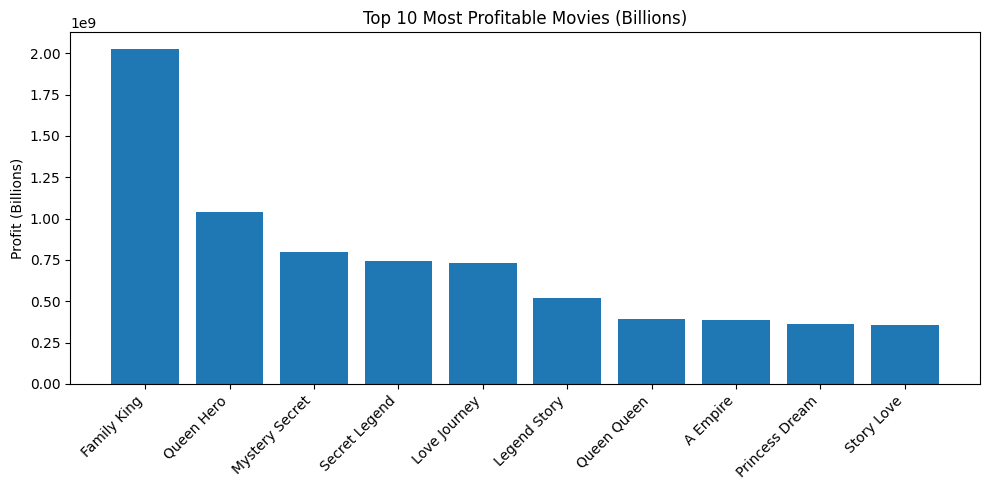

In [53]:
df_top10 = df_profit_movies.orderBy(col("profit").desc()).select("title", "profit").limit(10)

pdf = df_top10.toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf["title"], pdf["profit"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Profit (Billions)")
plt.title("Top 10 Most Profitable Movies (Billions)")
plt.tight_layout()
plt.show(10)